# Advanced Distribution Charts (Solution)

Use advanced distribution charts: ridgeline-like panels, beeswarm, raincloud-like combos.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/gapminder.csv")

root = resolve_repo_root()
df = pd.read_csv(root / "data" / "gapminder.csv")
d2007 = df[df["year"] == 2007].copy()


## 1) Ridgeline-like via stacked KDE facets

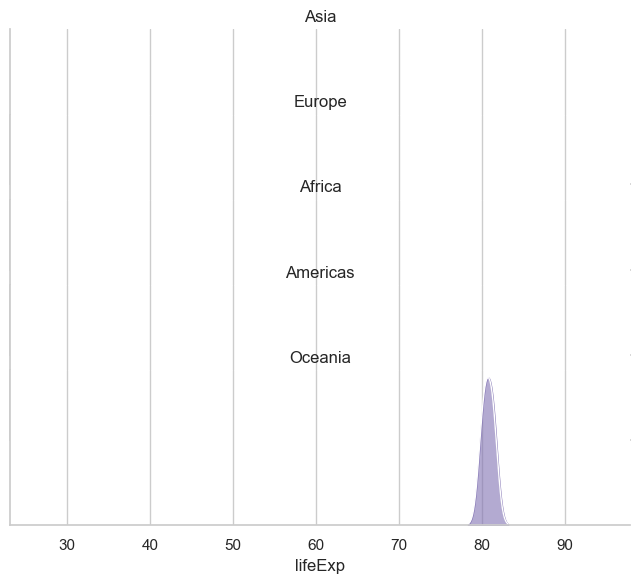

In [2]:
g = sns.FacetGrid(d2007, row="continent", hue="continent", aspect=6, height=1.2)
g.map(sns.kdeplot, "lifeExp", fill=True, alpha=0.6)
g.map(sns.kdeplot, "lifeExp", color="w", lw=1)
g.fig.subplots_adjust(hspace=-0.45)
g.set_titles(row_template='{row_name}')
for ax in g.axes.flat:
    ax.set_yticks([])
    ax.set_ylabel('')
plt.show()

## 2) Beeswarm (strip + jitter)

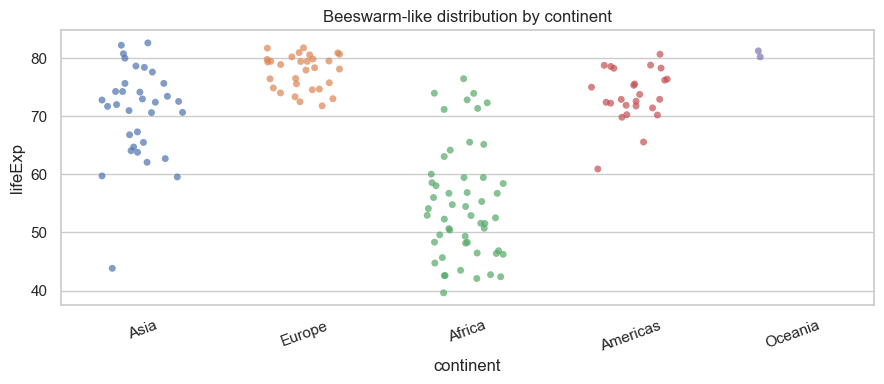

In [3]:
plt.figure(figsize=(9,4))
sns.stripplot(data=d2007, x='continent', y='lifeExp', hue='continent', jitter=0.25, dodge=False, alpha=0.7)
plt.xticks(rotation=20)
plt.title('Beeswarm-like distribution by continent')
plt.tight_layout(); plt.show()

## 3) Raincloud-like (violin + box + points)

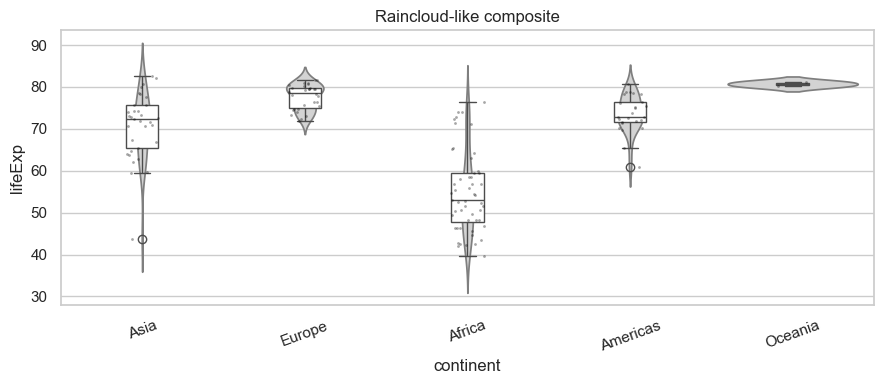

In [4]:
fig, ax = plt.subplots(figsize=(9,4))
sns.violinplot(data=d2007, x='continent', y='lifeExp', inner=None, color='lightgray', ax=ax)
sns.boxplot(data=d2007, x='continent', y='lifeExp', width=0.2, showcaps=True, boxprops={'facecolor':'white'}, ax=ax)
sns.stripplot(data=d2007, x='continent', y='lifeExp', color='black', size=2, alpha=0.35, ax=ax)
ax.tick_params(axis='x', rotation=20)
ax.set_title('Raincloud-like composite')
plt.tight_layout(); plt.show()

## 4) Contour density plot (2D KDE)

Dùng khi muốn thấy vùng mật độ cao/thấp của hai biến liên tục mà scatter thường bị chồng điểm.

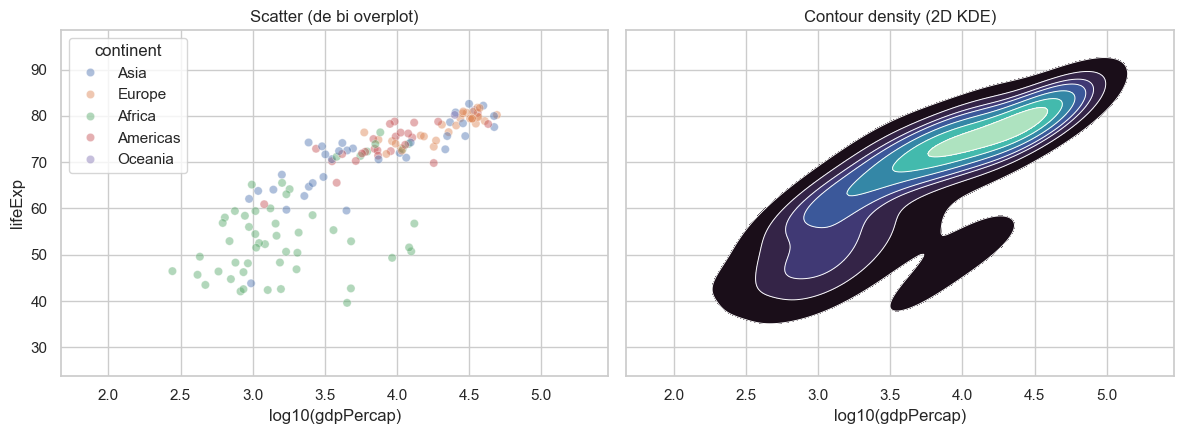

In [5]:
plot_df = d2007.copy()
plot_df["log_gdpPercap"] = np.log10(plot_df["gdpPercap"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

sns.scatterplot(
    data=plot_df,
    x="log_gdpPercap",
    y="lifeExp",
    hue="continent",
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_title("Scatter (de bi overplot)")

sns.kdeplot(
    data=plot_df,
    x="log_gdpPercap",
    y="lifeExp",
    fill=True,
    levels=8,
    thresh=0.05,
    cmap="mako",
    ax=axes[1],
)
sns.kdeplot(
    data=plot_df,
    x="log_gdpPercap",
    y="lifeExp",
    levels=8,
    color="white",
    linewidths=0.7,
    ax=axes[1],
)
axes[1].set_title("Contour density (2D KDE)")

for ax in axes:
    ax.set_xlabel("log10(gdpPercap)")
    ax.set_ylabel("lifeExp")

plt.tight_layout()
plt.show()

## Reflection
- Nêu 2 điểm học được về chart selection.
- Chỉ ra 1 rủi ro diễn giải sai với loại chart trong lab này.